# J-lens vs logit lens on a latent intermediate — latent-bridge v2, GPT-2 XL

In *"Toyota is a company from a country where the main language is"* the country (*Japan*) is
never named. Where in the prompt, and at which layers, can a lens read it, and does the J-lens
read it better than the logit lens? The prompts are the 530 candidates of
`data/experiments/latent-bridge-v2-candidates.json` (five subject families, 22 countries); 354 of
them form `latent-bridge-v2` (*kept*: GPT-2 XL names the country and its language when asked
directly, and answers the two-hop prompt).

**Answer (this run).** Yes, once the readout is not restricted to the last token. Over every position except the slot
where the country is the literal next word, the J-lens reads the country at rank 1 of the full
vocabulary for 48% of the 354 kept prompts against 24% for the logit lens (pass@10: 91% vs 63%).
On the subject tokens the J-lens finds it from a median layer 17 (logit lens: 31), in 80% of
prompts before the language appears at the last token. A difference-of-means probe built from
explicit mentions reads the country on the subject (top-1 of 22 countries, layers 12–36: probe
55%, logit lens 59%, J-lens 85%; control 7–10%), but hardly anywhere after it: at ` country` and
at the last token it is near chance in the middle layers (6%) and reaches 19% / 34% in layers
32–40, where both lenses reach 70–90%.

## Method

**Readout at every position.** One batched GPT-2 XL pass (fp32, `<|endoftext|>` prepended as
BOS, right padding; GPT-2 is causal, so real tokens never see padding) records every block
output at every prompt position. The logit lens decodes a block output `h` with the model's
`ln_f` and LM head (`jlens.readout.readout`); the J-lens first transports it, `h ← J_l h`
(`JacobianLens.transport`, `snapshot_lens_134.pt`, the lens of `concept_swap.ipynb`). Both lenses
share the model output at the last block. BOS is not scored.

**Words.** Per prompt: the *intermediate* (its country), a *control* (the country of another
prompt of the same family, never the prompt's own) and the *target* (the language). A word's rank
is the full-vocabulary rank (`jlens.readout.selected_token_ranks`) of its best whole-token
spelling (`DecodedSpellings`: as-is / lower / capitalized, with or without a leading space).

**Spans.** *subject*: the tokens of the subject (*Toyota*, *The Eiffel Tower*); *slot*: the
template token after which the country would be the literal next word (` in` in *"…is a city
in"*, ` from` in *"…is a company from"*), where the model simply predicts the country, so it is not
a latent readout and is kept apart; *country token*: ` country`; *other template*: the remaining
template tokens before the last; *last*: the last prompt token, where the answer is predicted
(the previous version of this benchmark read only there); *all but slot*: every non-BOS position
except the slot, the headline span; *all*: every non-BOS position.

**pass@k** (`jlens.evaluation.pass_at_k`): share of prompts whose word reaches rank ≤ k at some
(inner layer, position in the span) pair; the model output at the last block is excluded.
Subsets: all 530 prompts, and the 354 kept subjects.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# Opened from a clone (notebooks/<lens>/): use the repository root above the notebook.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "readout_cache.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch.nn.utils.rnn import pad_sequence
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

import jlens
from jlens.evaluation import pass_at_k
from jlens.hooks import ActivationRecorder
from jlens.readout import readout, selected_token_ranks
from jlens.strict_scoring import DecodedSpellings

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", None)

In [3]:
MODEL_ID = "openai-community/gpt2-xl"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", Path(REPO_DIR) / "runs" / "gpt2-xl-convergence"))
LENS_PATH = RUN_DIR / "snapshot_lens_134.pt"
OUT_DIR = RUN_DIR / "benchmark"
CACHE = OUT_DIR / "latent_bridge_v2_lens_positions.pkl"
SWAP_CACHE = RUN_DIR / "swap" / "swap_trials_latent-bridge-v2.csv"  # latent_bridge_v2_swap.ipynb
PROBE_PATH = RUN_DIR / "swap" / "probe_vectors_latent-bridge-v2.pt"  # latent_bridge_v2_swap.ipynb
CACHE22 = OUT_DIR / "latent_bridge_v2_country_ranks.pkl"
K_VALUES = [1, 5, 10, 100]
K = 10  # for layer and position profiles
BATCH_SIZE = 32  # prompts per forward pass
LENS_NAMES = ["logit lens", "J-lens"]
KINDS = ["intermediate", "control", "target"]
SPANS = ["subject", "country token", "other template", "last", "all but slot", "slot", "all"]
COLORS = {"logit lens": "#eb6834", "J-lens": "#2a78d6", "probe": "#1b9e5a"}
CONTROL_COLORS = {"logit lens": "#f4b183", "J-lens": "#9ecae1", "probe": "#a1d99b"}
METHODS = ["logit lens", "J-lens", "probe"]
# Half-open block-output ranges, as in concept_swap.ipynb; "0-47" is every inner layer.
BANDS = ["0-47", "8-16", "16-24", "24-32", "32-40", "40-47", "12-36", "16-40"]
BAND_TICKS = [band.replace("-", "–") for band in BANDS]
OUT_DIR.mkdir(parents=True, exist_ok=True)


def label_ends(ax, ends, gap=0.07):
    # Write each line's name at its right end, nudged apart vertically (in place of a legend).
    placed = []
    for y, text, color in sorted(ends):
        y = max(y, placed[-1] + gap) if placed else y
        placed.append(y)
        ax.annotate(text, xy=(1.01, y), xycoords=("axes fraction", "data"), color=color, fontsize=8,
                    va="center", annotation_clip=False)


def wilson(successes, n, z=1.96):
    p = successes / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return np.minimum(centre - half, p), np.maximum(centre + half, p)  # rounding never crosses p

## 1. Prompts

In [4]:
pool = json.loads((Path(REPO_DIR) / "data/experiments/latent-bridge-v2-candidates.json").read_text())
v2 = json.loads((Path(REPO_DIR) / "data/experiments/latent-bridge-v2.json").read_text())
LANG = pool["languages"]
FAMILIES = list(pool["families"])
kept_subjects = {(item["family"], item["subject"]) for item in v2["items"]}
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)


def sentence(template, subject):
    text = template.format(X=subject)
    return text[0].upper() + text[1:]


rows = []
for family, spec in pool["families"].items():
    pairs = [(country, subject) for country, subjects in spec["subjects"].items() for subject in subjects]
    for i, (country, subject) in enumerate(pairs):
        # Control: the country of the prompt half a list away, moving on until it differs.
        j = (i + len(pairs) // 2) % len(pairs)
        while pairs[j][0] == country:
            j = (j + 1) % len(pairs)
        prompt = sentence(spec["template"], subject)
        ids = [tokenizer.bos_token_id, *tokenizer(prompt).input_ids]
        subject_ids = tokenizer(prompt[:len(subject)]).input_ids
        assert ids[1:1 + len(subject_ids)] == subject_ids, prompt
        rows.append({"family": family, "subject": subject, "country": country, "control": pairs[j][0],
                     "language": LANG[country], "kept": (family, subject) in kept_subjects, "prompt": prompt,
                     "ids": ids, "n_subject": len(subject_ids)})
prompts = pd.DataFrame(rows)
assert prompts.kept.sum() == len(kept_subjects)
# Template tokens after the subject are the same for every prompt of a family.
TEMPLATE_TOKENS = {}
for family, group in prompts.groupby("family", sort=False):
    tails = {tuple(ids[1 + n:]) for ids, n in zip(group.ids, group.n_subject, strict=True)}
    assert len(tails) == 1, family
    TEMPLATE_TOKENS[family] = [tokenizer.decode([t]) for t in tails.pop()]
# " country" and the slot token two before it (the word before " a country").
COUNTRY_INDEX = {family: tokens.index(" country") for family, tokens in TEMPLATE_TOKENS.items()}
SLOT_INDEX = {family: index - 2 for family, index in COUNTRY_INDEX.items()}
assert all(TEMPLATE_TOKENS[f][i + 1] == " a" for f, i in SLOT_INDEX.items())
display(prompts.groupby("family", sort=False).agg(prompts=("subject", "size"), kept=("kept", "sum"),
                                                   subject_tokens=("n_subject", "mean")).round(2))
pd.DataFrame({"template tokens after the subject": {f: "|".join(t) for f, t in TEMPLATE_TOKENS.items()},
              "slot": {f: repr(TEMPLATE_TOKENS[f][i]) for f, i in SLOT_INDEX.items()}})

,prompts,kept,subject_tokens
family,,,
landmark,108,71,4.23
city,119,98,2.74
person,117,83,3.59
brand,83,49,2.58
food,103,53,3.34


,template tokens after the subject,slot
landmark,is| in| a| country| where| the| main| language| is,' in'
city,is| a| city| in| a| country| where| the| main| language| is,' in'
person,was| born| in| a| country| where| the| main| language| is,' in'
brand,is| a| company| from| a| country| where| the| main| language| is,' from'
food,comes| from| a| country| where| the| main| language| is,' from'


## 2. Ranks at every (layer, position)

For each prompt and word: a `[layer, position]` rank array (48 block outputs, the last being
the shared model output; positions 1…T−1, BOS excluded). Cached to `CACHE` and skipped when
present (the model is then not loaded).

In [5]:
if not CACHE.exists():
    hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32).to(DEVICE).eval()
    model = jlens.from_hf(hf_model, tokenizer, compile=False, force_bos=False)
    lens = jlens.JacobianLens.load(str(LENS_PATH))
    N_LAYERS = model.n_layers
    jacobians = {layer: lens.jacobians[layer].to(DEVICE, torch.float32) for layer in range(N_LAYERS - 1)}
    spellings = DecodedSpellings(tokenizer, vocab_size=hf_model.get_output_embeddings().weight.shape[0])

    def spelling_row(word):
        ids = sorted(spellings(word, False))
        assert ids, word
        return ids

    width = max(len(spelling_row(w)) for w in set(prompts.country) | set(prompts.control) | set(prompts.language))

    def padded_ids(words):
        # [n, width] spelling ids, padded by repeating each row's first id (ranks are min-reduced).
        rows = [spelling_row(w) for w in words]
        return torch.tensor([r + r[:1] * (width - len(r)) for r in rows])

    order = np.argsort(prompts.ids.map(len).to_numpy(), kind="stable")
    ranks = {}  # (prompt index, lens, kind) -> [layer, position] int32
    model_top1 = {}
    with torch.no_grad():
        for start in tqdm(range(0, len(order), BATCH_SIZE), desc="batches"):
            index = order[start:start + BATCH_SIZE]
            chunk = prompts.iloc[index]
            lengths = chunk.ids.map(len).to_numpy()
            ids = pad_sequence([torch.tensor(i) for i in chunk.ids], batch_first=True,
                               padding_value=tokenizer.eos_token_id).to(DEVICE)
            with ActivationRecorder(model.layers, at=range(N_LAYERS)) as recorder:
                hf_model(input_ids=ids)
            # Every real non-BOS position of the batch, flattened.
            rows = torch.tensor(np.concatenate([np.full(n - 1, b) for b, n in enumerate(lengths)]), device=DEVICE)
            positions = torch.tensor(np.concatenate([np.arange(1, n) for n in lengths]), device=DEVICE)
            words = torch.stack([padded_ids(chunk[column]) for column in ("country", "control", "language")], 1)
            words = words.to(DEVICE)[rows].reshape(len(rows), -1)  # [P, 3 * width]
            out = torch.empty(len(LENS_NAMES), N_LAYERS, len(rows), len(KINDS), dtype=torch.int32, device=DEVICE)
            for layer in range(N_LAYERS):
                h = recorder.activations[layer][rows, positions].float()
                for li, lens_name in enumerate(LENS_NAMES):
                    residual = h @ jacobians[layer].T if lens_name == "J-lens" and layer < N_LAYERS - 1 else h
                    scores = readout(model, residual).ranking_scores
                    r = selected_token_ranks(scores, words).reshape(len(rows), len(KINDS), width).min(-1).values
                    out[li, layer] = r.to(torch.int32)
                    if layer == N_LAYERS - 1 and li == 0:
                        top1 = scores.argmax(-1)
            out, top1 = out.cpu().numpy(), top1.cpu().numpy()  # one transfer per batch
            offsets = np.concatenate([[0], np.cumsum(lengths - 1)])
            for b, prompt_index in enumerate(index):
                span = slice(offsets[b], offsets[b + 1])
                for li, lens_name in enumerate(LENS_NAMES):
                    for ki, kind in enumerate(KINDS):
                        ranks[prompt_index, lens_name, kind] = out[li, :, span, ki]
                model_top1[prompt_index] = int(top1[offsets[b + 1] - 1])
            del recorder
    pd.to_pickle({"ranks": ranks, "model_top1": model_top1, "lens": str(LENS_PATH), "model": MODEL_ID,
                  "dtype": "float32", "bos": "prepend"}, CACHE)
    model = hf_model = lens = jacobians = None
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
cached = pd.read_pickle(CACHE)
RANKS = cached["ranks"]
N_LAYERS = next(iter(RANKS.values())).shape[0]
language_ids = {w: set(DecodedSpellings(tokenizer, vocab_size=len(tokenizer))(w, False)) for w in set(prompts.language)}
prompts["model_correct"] = [cached["model_top1"][i] in language_ids[w] for i, w in enumerate(prompts.language)]
print(f"{len(prompts)} prompts, {N_LAYERS} block outputs (last = model output)")
display(prompts.groupby(["family", "kept"], sort=False).model_correct.agg(["size", "mean"]).round(3).rename(
    columns={"size": "prompts", "mean": "model correct"}))
assert prompts[prompts.kept].model_correct.all()

530 prompts, 48 block outputs (last = model output)


prompts  model correct
family   kept                         
landmark True        71          1.000
         False       37          0.081
city     True        98          1.000
         False       21          0.048
person   True        83          1.000
         False       34          0.176
brand    True        49          1.000
         False       34          0.118
food     True        53          1.000
         False       50          0.160

## 3. pass@k by span

`pass_at_k` on per-layer ranks reduced (min) over the positions of each span, over every inner
layer (layers 0–46; the model output at layer 47 is excluded).

In [6]:
def span_positions(family, n_subject, n_positions):
    # Column indices into the [layer, position] arrays (position 1 is column 0).
    slot, country, last = n_subject + SLOT_INDEX[family], n_subject + COUNTRY_INDEX[family], n_positions - 1
    every = np.arange(n_positions)
    return {"subject": np.arange(0, n_subject), "country token": np.array([country]),
            "other template": np.setdiff1d(np.arange(n_subject, last), [slot, country]),
            "last": np.array([last]), "all but slot": np.setdiff1d(every, [slot]),
            "slot": np.array([slot]), "all": every}


word_rows = []
for i, row in prompts.iterrows():
    for lens_name in LENS_NAMES:
        for kind in KINDS:
            array = RANKS[i, lens_name, kind]
            for span, columns in span_positions(row.family, row.n_subject, array.shape[1]).items():
                word_rows.append({"lens": lens_name, "dataset": row.family, "kind": kind, "span": span,
                                  "item": f"{row.family}:{row.subject}", "kept": row.kept, "word": row[
                                      {"intermediate": "country", "control": "control", "target": "language"}[kind]],
                                  "ranks": array[:, columns].min(1)})
words = pd.DataFrame(word_rows)
INNER = slice(None, -1)


def pass_table(frame, ks=K_VALUES):
    rows = []
    for span in SPANS:
        scores = pass_at_k(frame[frame.span.eq(span)].drop(columns="dataset").assign(dataset="all"), ks, INNER)
        rows.append(scores.assign(span=span))
    table = pd.concat(rows).pivot_table(index=["kind", "span", "lens"], columns="k", values="score")
    table.columns = [f"pass@{k}, layers 0–46" for k in table.columns]
    return table.reindex(KINDS, level="kind").reindex(SPANS, level="span").round(3)


print("kept subjects (n = 354)")
display(pass_table(words[words.kept]))
print("all prompts (n = 530)")
display(pass_table(words))

kept subjects (n = 354)


pass@1, layers 0–46  pass@5, layers 0–46  pass@10, layers 0–46  pass@100, layers 0–46
kind         span           lens                                                                                             
intermediate subject        J-lens                    0.169                0.427                 0.551                  0.910
                            logit lens                0.175                0.331                 0.432                  0.802
             country token  J-lens                    0.161                0.497                 0.672                  0.972
                            logit lens                0.000                0.020                 0.096                  0.726
             other template J-lens                    0.345                0.585                 0.715                  0.989
                            logit lens                0.138                0.412                 0.551                  0.980
             last           J-lens                    0.000                0.031                 0.178                  0.938
                            logit lens                0.000                0.099                 0.314                  0.949
             all but slot   J-lens                    0.477                0.805                 0.907                  1.000
                            logit lens                0.237                0.494                 0.630                  0.997
             slot           J-lens                    0.698                0.904                 0.960                  0.997
                            logit lens                0.760                0.924                 0.960                  0.997
             all            J-lens                    0.766                0.958                 0.986                  1.000
                            logit lens                0.780                0.952                 0.975                  1.000
control      subject        J-lens                    0.000                0.003                 0.008                  0.099
                            logit lens                0.000                0.000                 0.000                  0.034
             country token  J-lens                    0.011                0.093                 0.195                  0.782
                            logit lens                0.000                0.000                 0.000                  0.088
             other template J-lens                    0.011                0.045                 0.071                  0.500
                            logit lens                0.000                0.003                 0.008                  0.364
             last           J-lens                    0.000                0.000                 0.000                  0.040
                            logit lens                0.000                0.000                 0.000                  0.059
             all but slot   J-lens                    0.023                0.127                 0.226                  0.839
                            logit lens                0.000                0.003                 0.008                  0.418
             slot           J-lens                    0.006                0.031                 0.059                  0.537
                            logit lens                0.014                0.042                 0.079                  0.689
             all            J-lens                    0.025                0.141                 0.246                  0.870
                            logit lens                0.014                0.045                 0.082                  0.766
target       subject        J-lens                    0.071                0.347                 0.508                  0.881
                            logit lens                0.085                0.268                 0.370                  0.749
        

all prompts (n = 530)


pass@1, layers 0–46  pass@5, layers 0–46  pass@10, layers 0–46  pass@100, layers 0–46
kind         span           lens                                                                                             
intermediate subject        J-lens                    0.126                0.325                 0.449                  0.808
                            logit lens                0.136                0.281                 0.364                  0.670
             country token  J-lens                    0.121                0.404                 0.579                  0.949
                            logit lens                0.000                0.013                 0.072                  0.638
             other template J-lens                    0.270                0.492                 0.598                  0.942
                            logit lens                0.119                0.325                 0.440                  0.887
             last           J-lens                    0.000                0.023                 0.132                  0.789
                            logit lens                0.000                0.077                 0.249                  0.800
             all but slot   J-lens                    0.372                0.681                 0.792                  0.987
                            logit lens                0.191                0.398                 0.515                  0.934
             slot           J-lens                    0.600                0.796                 0.877                  0.977
                            logit lens                0.638                0.806                 0.870                  0.970
             all            J-lens                    0.657                0.866                 0.919                  0.996
                            logit lens                0.653                0.828                 0.883                  0.987
control      subject        J-lens                    0.000                0.004                 0.009                  0.119
                            logit lens                0.000                0.002                 0.002                  0.040
             country token  J-lens                    0.008                0.096                 0.208                  0.783
                            logit lens                0.000                0.000                 0.000                  0.085
             other template J-lens                    0.008                0.032                 0.055                  0.474
                            logit lens                0.000                0.002                 0.008                  0.355
             last           J-lens                    0.000                0.000                 0.000                  0.042
                            logit lens                0.000                0.000                 0.000                  0.068
             all but slot   J-lens                    0.015                0.121                 0.236                  0.858
                            logit lens                0.000                0.004                 0.009                  0.415
             slot           J-lens                    0.004                0.040                 0.087                  0.549
                            logit lens                0.015                0.057                 0.102                  0.711
             all            J-lens                    0.017                0.145                 0.281                  0.879
                            logit lens                0.015                0.058                 0.106                  0.792
target       subject        J-lens                    0.070                0.294                 0.426                  0.806
                            logit lens                0.074                0.226                 0.304                  0.643
        

### pass@k by band of layers

As in `concept_swap.ipynb`, the x axis is the band of layers the readout is restricted to; with one
word per prompt, pass@k is a proportion of prompts, shown with Wilson 95% intervals. Country and
control country (another country of the same family), J-lens and logit lens, kept subjects.

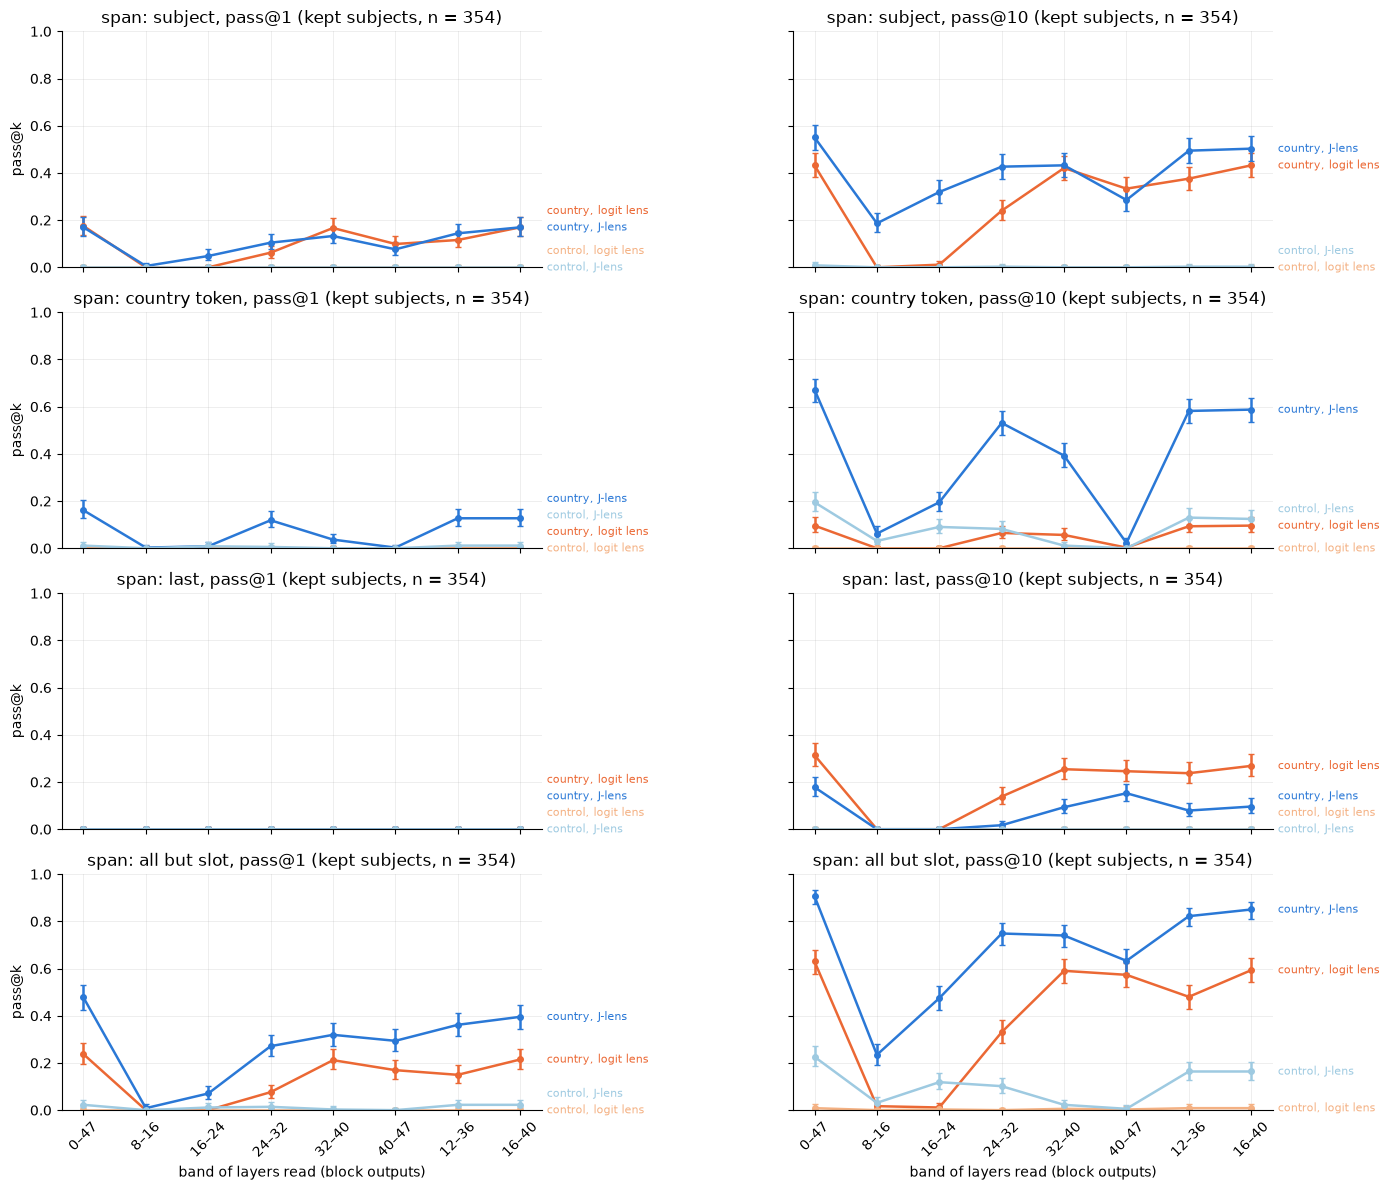

In [7]:
kept_words = words[words.kept]


def band_pass(frame, k):
    """[band] (hits, n): the word reaches rank <= k at some layer of the band and position of the span."""
    ranks = np.stack(frame.ranks.to_numpy())
    out = []
    for band in BANDS:
        lo, hi = map(int, band.split("-"))
        out.append(((ranks[:, lo:hi].min(1) <= k).sum(), len(ranks)))
    return np.array(out)


def pass_panel(ax, frame, span, k, methods=LENS_NAMES):
    ends = []
    for lens_name in methods:
        for kind, colors, name in (("intermediate", COLORS, "country"), ("control", CONTROL_COLORS, "control")):
            sub = frame[frame.span.eq(span) & frame.lens.eq(lens_name) & frame.kind.eq(kind)]
            hits, n = band_pass(sub, k).T
            rate = hits / n
            lo, hi = wilson(hits, n)
            ax.errorbar(range(len(BANDS)), rate, yerr=[rate - lo, hi - rate], color=colors[lens_name], marker="o",
                        ms=4, lw=1.8, capsize=2)
            ends.append((rate[-1], f"{name}, {lens_name}", colors[lens_name]))
    label_ends(ax, ends)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25, lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)


PANEL_SPANS = ["subject", "country token", "last", "all but slot"]
fig, axes = plt.subplots(len(PANEL_SPANS), 2, figsize=(14, 3 * len(PANEL_SPANS)), sharex=True, sharey=True)
for row_axes, span in zip(axes, PANEL_SPANS, strict=True):
    for ax, k in zip(row_axes, [1, K], strict=True):
        pass_panel(ax, kept_words, span, k)
        ax.set_title(f"span: {span}, pass@{k} (kept subjects, n = {prompts.kept.sum()})")
    row_axes[0].set_ylabel("pass@k")
for ax in axes[-1]:
    ax.set_xticks(range(len(BANDS)), BAND_TICKS, rotation=45)
    ax.set_xlabel("band of layers read (block outputs)")
fig.tight_layout(w_pad=10)
plt.show()

By family, pass@10 on the subject span and on all positions but the slot:

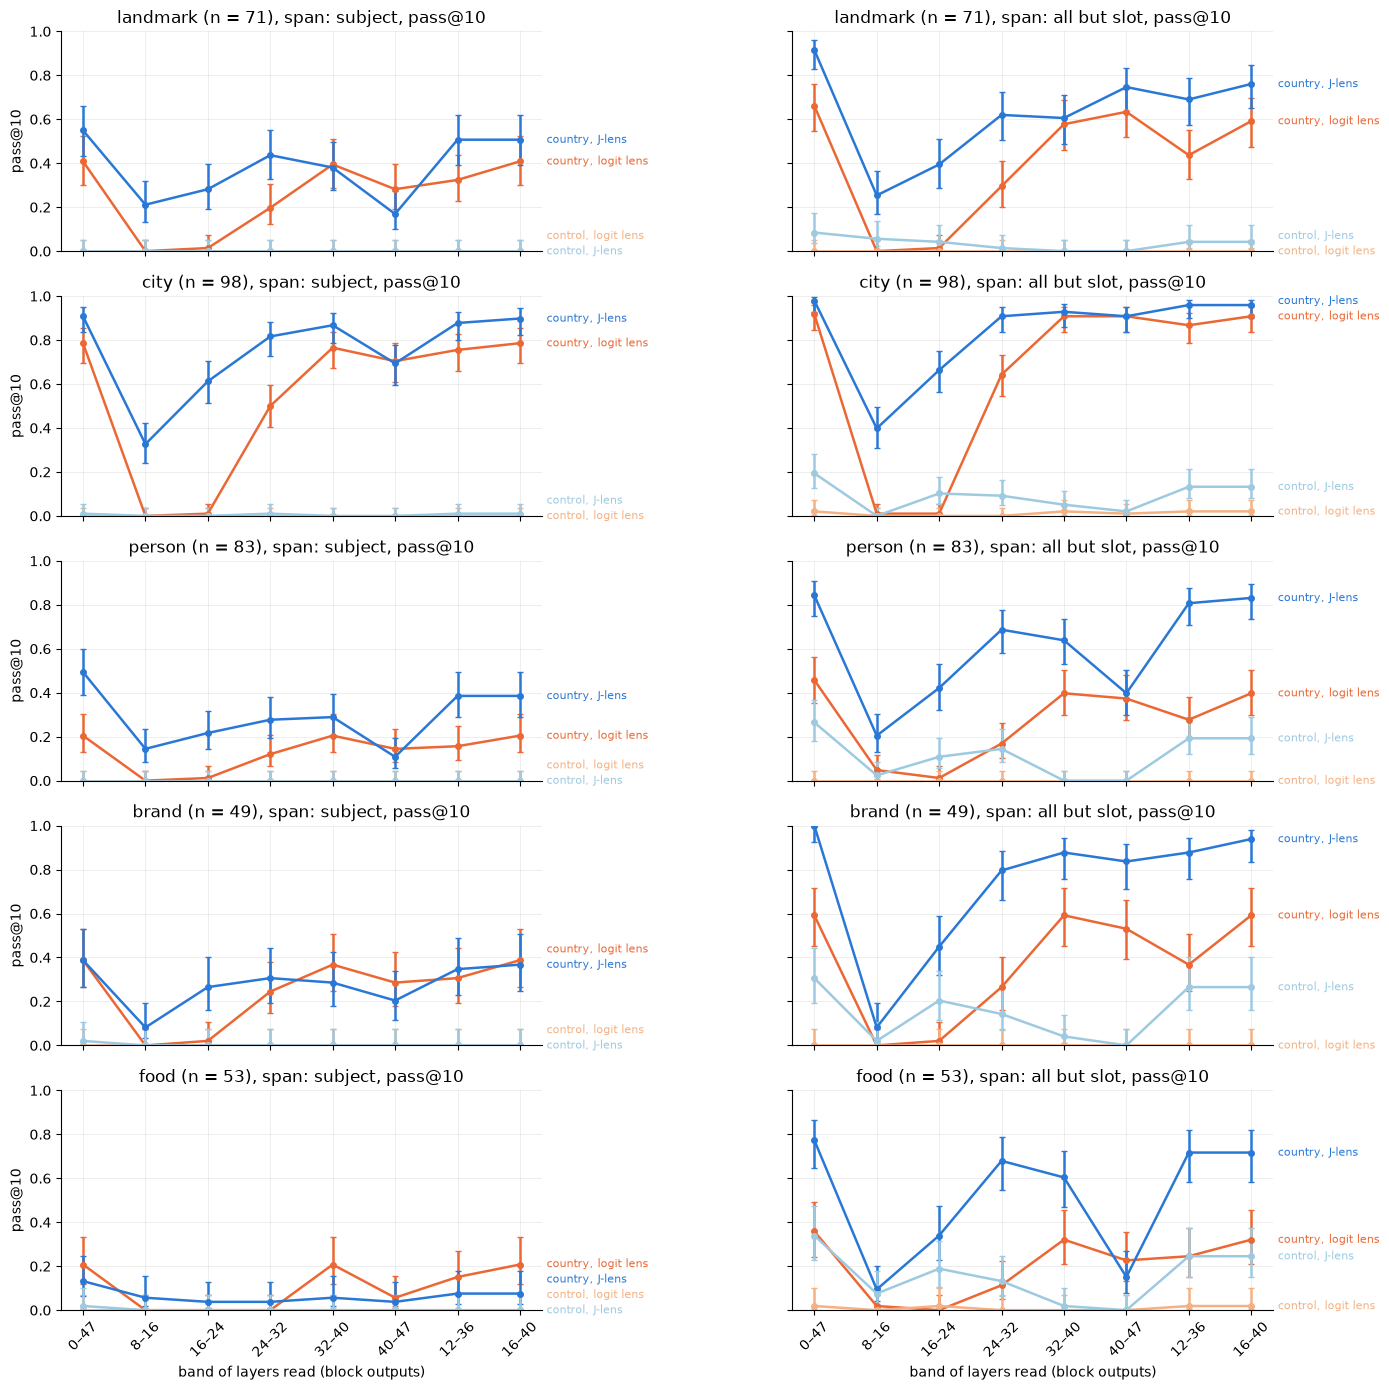

In [8]:
fig, axes = plt.subplots(len(FAMILIES), 2, figsize=(14, 2.8 * len(FAMILIES)), sharex=True, sharey=True)
for row_axes, family in zip(axes, FAMILIES, strict=True):
    frame = kept_words[kept_words.dataset.eq(family)]
    for ax, span in zip(row_axes, ["subject", "all but slot"], strict=True):
        pass_panel(ax, frame, span, K)
        ax.set_title(f"{family} (n = {frame.item.nunique()}), span: {span}, pass@{K}")
    row_axes[0].set_ylabel(f"pass@{K}")
for ax in axes[-1]:
    ax.set_xticks(range(len(BANDS)), BAND_TICKS, rotation=45)
    ax.set_xlabel("band of layers read (block outputs)")
fig.tight_layout(w_pad=10)
plt.show()

## 4. Where and when: layer × position maps

Share of kept prompts with the country at rank ≤ 10, per layer and position. Within a family the
template is fixed, so positions align: the first column is the subject (min over its tokens),
then each template token; the last column is the position that predicts the answer. The slot
column (` in` / ` from`) is where the country is the literal next word.

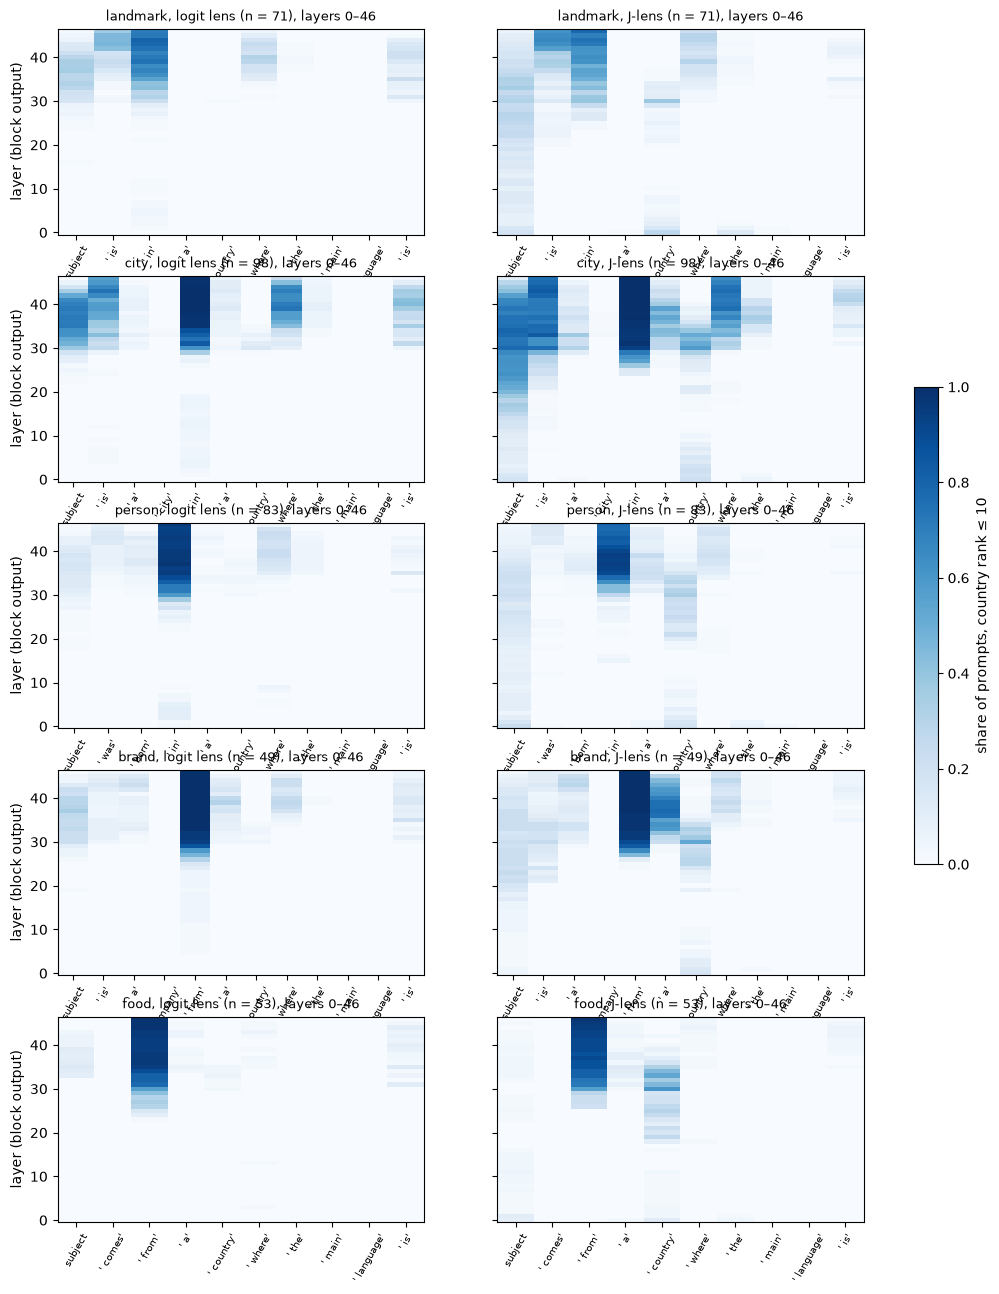

In [9]:
fig, axes = plt.subplots(len(FAMILIES), 2, figsize=(13, 3.1 * len(FAMILIES)), sharey=True)
for row_axes, family in zip(axes, FAMILIES, strict=True):
    group = prompts[prompts.kept & prompts.family.eq(family)]
    columns = ["subject"] + TEMPLATE_TOKENS[family]
    for ax, lens_name in zip(row_axes, LENS_NAMES, strict=True):
        maps = []
        for i, row in group.iterrows():
            array = RANKS[i, lens_name, "intermediate"][:-1]  # inner layers
            maps.append(np.column_stack([array[:, :row.n_subject].min(1), array[:, row.n_subject:]]) <= K)
        image = np.mean(maps, 0)
        mesh = ax.imshow(image, aspect="auto", origin="lower", cmap="Blues", vmin=0, vmax=1,
                         extent=(-0.5, len(columns) - 0.5, -0.5, image.shape[0] - 0.5))
        ax.set_xticks(range(len(columns)), [repr(c) if c != "subject" else c for c in columns], rotation=60,
                      fontsize=7)
        ax.set_title(f"{family}, {lens_name} (n = {len(group)}), layers 0–46", fontsize=9)
    row_axes[0].set_ylabel("layer (block output)")
fig.colorbar(mesh, ax=axes, shrink=0.4, label=f"share of prompts, country rank ≤ {K}")
plt.show()

### Layer profiles

Per inner layer, share of kept prompts with rank ≤ 10, one panel per word and position: the
country on the subject span, at ` country` and at the last token, the control country on the
subject span, and the language at the last token.

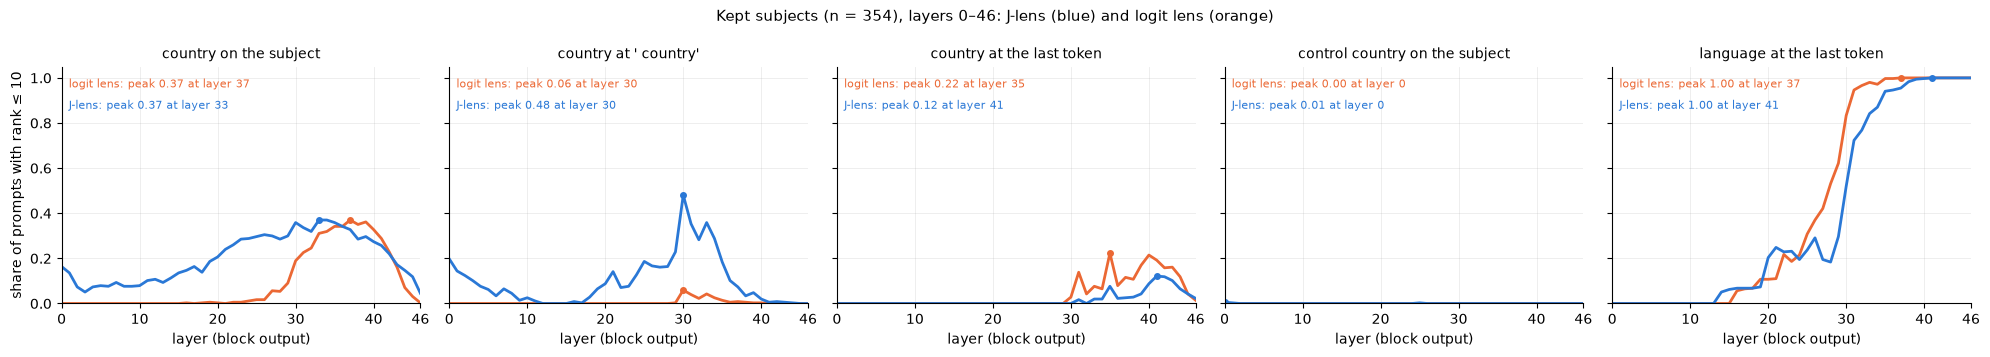

In [10]:
PROFILES = [("intermediate", "subject", "country on the subject"),
            ("intermediate", "country token", "country at ' country'"),
            ("intermediate", "last", "country at the last token"),
            ("control", "subject", "control country on the subject"),
            ("target", "last", "language at the last token")]
fig, axes = plt.subplots(1, len(PROFILES), figsize=(4 * len(PROFILES), 3.6), sharey=True)
for ax, (kind, span, title) in zip(axes, PROFILES, strict=True):
    peaks = []
    for lens_name in LENS_NAMES:
        sub = kept_words[kept_words.lens.eq(lens_name) & kept_words.kind.eq(kind) & kept_words.span.eq(span)]
        curve = (np.stack(sub.ranks.to_numpy())[:, :-1] <= K).mean(0)
        ax.plot(curve, color=COLORS[lens_name], lw=2)
        peak = int(curve.argmax())
        ax.plot(peak, curve[peak], "o", color=COLORS[lens_name], ms=4)
        ax.text(0.02, 0.95 - 0.09 * LENS_NAMES.index(lens_name), f"{lens_name}: peak {curve[peak]:.2f} at layer {peak}",
                transform=ax.transAxes, color=COLORS[lens_name], fontsize=8, va="top")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("layer (block output)")
    ax.set_xlim(0, N_LAYERS - 2)
    ax.set_xticks([0, 10, 20, 30, 40, N_LAYERS - 2])
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.25, lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel(f"share of prompts with rank ≤ {K}")
fig.suptitle(f"Kept subjects (n = {prompts.kept.sum()}), layers 0–46: J-lens (blue) and logit lens (orange)",
             fontsize=11)
fig.tight_layout()
plt.show()

### Does the country appear before the answer?

First inner layer at which the country reaches rank ≤ 10 on the subject span, against the first
layer at which the language does at the last token, per kept prompt.

In [11]:
def first_layer(ranks, k):
    hit = ranks[:, :-1] <= k
    return np.where(hit.any(1), hit.argmax(1), -1)


rows = []
for lens_name in LENS_NAMES:
    sub = kept_words[kept_words.lens.eq(lens_name)].set_index(["dataset", "item", "kind", "span"]).ranks
    keys = list(prompts[prompts.kept][["family", "subject"]].itertuples(index=False))
    country = first_layer(np.stack([sub[f, f"{f}:{s}", "intermediate", "subject"] for f, s in keys]), K)
    language = first_layer(np.stack([sub[f, f"{f}:{s}", "target", "last"] for f, s in keys]), K)
    both = (country >= 0) & (language >= 0)
    gap = language[both] - country[both]
    rows.append({"lens": lens_name, "country reached": int((country >= 0).sum()),
                 "median first layer, country @ subject": np.median(country[country >= 0]),
                 "language reached": int((language >= 0).sum()),
                 "median first layer, language @ last": np.median(language[language >= 0]),
                 "both": int(both.sum()), "country first": (gap > 0).mean(), "same layer": (gap == 0).mean(),
                 "language first": (gap < 0).mean(), "median gap (layers)": np.median(gap)})
pd.DataFrame(rows).set_index("lens").round(2).T

lens,logit lens,J-lens
country reached,153.00,195.00
"median first layer, country @ subject",31.00,17.00
language reached,354.00,354.00
"median first layer, language @ last",28.00,30.00
both,153.00,195.00
country first,0.13,0.80
same layer,0.12,0.05
language first,0.75,0.15
median gap (layers),-3.00,11.00


## 5. Does lens visibility predict swap success?

For each kept subject, the country's best rank over the *all but slot* positions and the layers
of the best J swap setting, against that swap's success (from `latent_bridge_v2_swap.ipynb`).

In [12]:
if SWAP_CACHE.exists():
    swaps = pd.read_csv(SWAP_CACHE, keep_default_na=False)
    swaps["success"] = swaps.success.astype(str).eq("True")
    j = swaps[swaps["mode"].eq("J")]
    best_setting = j.groupby(["alpha", "band"]).success.mean().idxmax()
    lo, hi = map(int, best_setting[1].split("-"))
    at_best = j[j.alpha.eq(best_setting[0]) & j.band.eq(best_setting[1])]
    print(f"best J swap setting: alpha = {best_setting[0]:g}, band {best_setting[1]}, "
          f"success {at_best.success.mean():.3f}")
    bins, labels = [0, 1, 10, 100, 1000, np.inf], ["1", "2-10", "11-100", "101-1000", ">1000"]
    index = {(r.family, r.subject): i for i, r in prompts.iterrows()}
    tables = []
    for lens_name in LENS_NAMES:
        band_rank = []
        for f, s in zip(at_best.family, at_best.subject, strict=True):
            i = index[f, s]
            array = RANKS[i, lens_name, "intermediate"]
            columns = span_positions(f, prompts.n_subject[i], array.shape[1])["all but slot"]
            band_rank.append(array[lo:hi][:, columns].min())
        binned = at_best.assign(rank_bin=pd.cut(band_rank, bins, labels=labels))
        tables.append(binned.groupby("rank_bin", observed=False).success.agg(["size", "mean"]).rename(
            columns={"size": f"trials ({lens_name})", "mean": f"success ({lens_name})"}))
    display(pd.concat(tables, axis=1).round(3))
else:
    print("no swap results at", SWAP_CACHE, "- run latent_bridge_v2_swap.ipynb first")

best J swap setting: alpha = 2, band 12-36, success 0.919


,trials (logit lens),success (logit lens),trials (J-lens),success (J-lens)
rank_bin,,,,
1,212,0.953,512,0.934
2-10,468,0.936,652,0.929
11-100,708,0.908,240,0.871
101-1000,28,0.679,12,0.750
>1000,0,NaN,0,NaN


## 6. Readout among the 22 countries: probe vs lenses

Which of the 22 countries does a residual `h` represent? Three readouts, none of which changes
the model:

* **probe**: `score_c = w_c · h`, with the difference-of-means directions `w_c` the probe swaps
  of `latent_bridge_v2_swap.ipynb` use (country token in the 20 neutral templates of
  `concept-probe-templates.json`, minus the mean over countries);
* **logit lens** / **J-lens**: the logit of the country's best whole-token spelling, read from `h`
  (or `J_l h`) as above, but compared only with the other 21 countries.

For each method the country and the control country are ranked among the 22 at every (inner
layer, position). With only 22 candidates, a best-over-layers score (pass@k as in §3) saturates:
some wrong country is first somewhere in the span for most prompts. The metric here is therefore
**top-1 accuracy among the 22, averaged over the layers of a band**: for each prompt and layer,
is the country (min rank over the span's positions) first; then the mean over the band's layers
and the prompts. Chance is about 1/22 per position; the control country shows the actual floor.
Needs the probe vectors from `latent_bridge_v2_swap.ipynb`; one model pass, cached to `CACHE22`.

In [13]:
COUNTRIES = sorted(LANG)
if not CACHE22.exists():
    probe = torch.load(PROBE_PATH)
    assert probe["concepts"] == COUNTRIES, "probe vectors must cover the 22 countries in sorted order"
    hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32).to(DEVICE).eval()
    model = jlens.from_hf(hf_model, tokenizer, compile=False, force_bos=False)
    lens = jlens.JacobianLens.load(str(LENS_PATH))
    N_INNER = model.n_layers - 1
    jacobians = {layer: lens.jacobians[layer].to(DEVICE, torch.float32) for layer in range(N_INNER)}
    probe_vectors = probe["vectors"].to(DEVICE, torch.float32)  # [layer, country, d]
    spellings = DecodedSpellings(tokenizer, vocab_size=hf_model.get_output_embeddings().weight.shape[0])
    rows_ids = [sorted(spellings(c, False)) for c in COUNTRIES]
    width = max(map(len, rows_ids))
    country_ids = torch.tensor([r + r[:1] * (width - len(r)) for r in rows_ids], device=DEVICE)  # [22, width]
    position_of = {c: i for i, c in enumerate(COUNTRIES)}
    order = np.argsort(prompts.ids.map(len).to_numpy(), kind="stable")
    ranks22 = {}
    with torch.no_grad():
        for start in tqdm(range(0, len(order), BATCH_SIZE), desc="batches"):
            index = order[start:start + BATCH_SIZE]
            chunk = prompts.iloc[index]
            lengths = chunk.ids.map(len).to_numpy()
            ids = pad_sequence([torch.tensor(i) for i in chunk.ids], batch_first=True,
                               padding_value=tokenizer.eos_token_id).to(DEVICE)
            with ActivationRecorder(model.layers, at=range(N_INNER)) as recorder:
                hf_model(input_ids=ids)
            rows = torch.tensor(np.concatenate([np.full(n - 1, b) for b, n in enumerate(lengths)]), device=DEVICE)
            positions = torch.tensor(np.concatenate([np.arange(1, n) for n in lengths]), device=DEVICE)
            truth = torch.tensor([[position_of[c], position_of[k]] for c, k in zip(chunk.country, chunk.control,
                                                                                   strict=True)], device=DEVICE)[rows]
            out = torch.empty(len(METHODS), N_INNER, len(rows), 2, dtype=torch.int32, device=DEVICE)
            for layer in range(N_INNER):
                h = recorder.activations[layer][rows, positions].float()
                for mi, method in enumerate(METHODS):
                    if method == "probe":
                        scores = h @ probe_vectors[layer].T  # [P, 22]
                    else:
                        residual = h @ jacobians[layer].T if method == "J-lens" else h
                        logits = readout(model, residual).ranking_scores
                        scores = logits[:, country_ids].max(-1).values  # [P, 22]
                    chosen = scores.gather(1, truth)  # [P, 2]: country, control
                    out[mi, layer] = ((scores[:, None, :] > chosen[..., None]).sum(-1) + 1).to(torch.int32)
            out = out.cpu().numpy()  # one transfer per batch
            offsets = np.concatenate([[0], np.cumsum(lengths - 1)])
            for b, prompt_index in enumerate(index):
                span = slice(offsets[b], offsets[b + 1])
                for mi, method in enumerate(METHODS):
                    for ki, kind in enumerate(["intermediate", "control"]):
                        ranks22[prompt_index, method, kind] = out[mi, :, span, ki]
            del recorder
    pd.to_pickle({"ranks": ranks22, "countries": COUNTRIES, "probe": str(PROBE_PATH), "lens": str(LENS_PATH),
                  "model": MODEL_ID, "dtype": "float32", "bos": "prepend"}, CACHE22)
    model = hf_model = lens = jacobians = probe_vectors = None
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
RANKS22 = pd.read_pickle(CACHE22)["ranks"]

rows22 = []
for i, row in prompts.iterrows():
    for method in METHODS:
        for kind in ["intermediate", "control"]:
            array = RANKS22[i, method, kind]
            for span, columns in span_positions(row.family, row.n_subject, array.shape[1]).items():
                rows22.append({"lens": method, "dataset": row.family, "kind": kind, "span": span,
                               "item": f"{row.family}:{row.subject}", "kept": row.kept,
                               "ranks": array[:, columns].min(1)})
words22 = pd.DataFrame(rows22)
kept22 = words22[words22.kept]


def band_accuracy(frame, band):
    """Per prompt: share of the band's layers at which the word is ranked first among the 22."""
    lo, hi = map(int, band.split("-"))
    return (np.stack(frame.ranks.to_numpy())[:, lo:hi] <= 1).mean(1)


TABLE_BANDS = ["0-47", "12-36", "16-40", "32-40"]
rows = []
for (span, method, kind), frame in kept22.groupby(["span", "lens", "kind"]):
    rows.append({"span": span, "readout": method, "word": "country" if kind == "intermediate" else "control",
                 **{f"layers {b.replace('-', '–')}": band_accuracy(frame, b).mean() for b in TABLE_BANDS}})
accuracy22 = pd.DataFrame(rows).set_index(["span", "readout", "word"])
print(f"top-1 among 22, mean over the band's layers; kept subjects (n = {prompts.kept.sum()})")
accuracy22.reindex(pd.MultiIndex.from_product([SPANS, METHODS, ["country", "control"]])).round(3)

top-1 among 22, mean over the band's layers; kept subjects (n = 354)


layers 0–47  layers 12–36  layers 16–40  layers 32–40
subject        logit lens country        0.600         0.594         0.688         0.916
                          control        0.099         0.096         0.092         0.085
               J-lens     country        0.808         0.853         0.883         0.936
                          control        0.080         0.071         0.071         0.072
               probe      country        0.495         0.550         0.624         0.784
                          control        0.083         0.077         0.079         0.093
country token  logit lens country        0.385         0.283         0.409         0.797
                          control        0.028         0.024         0.019         0.004
               J-lens     country        0.343         0.250         0.364         0.690
                          control        0.024         0.030         0.023         0.004
               probe      country        0.069         0.063         0.094         0.192
                          control        0.047         0.047         0.048         0.052
other template logit lens country        0.623         0.581         0.684         0.968
                          control        0.218         0.241         0.224         0.165
               J-lens     country        0.622         0.556         0.666         0.964
                          control        0.196         0.210         0.184         0.102
               probe      country        0.157         0.122         0.192         0.371
                          control        0.092         0.075         0.085         0.097
last           logit lens country        0.400         0.272         0.417         0.868
                          control        0.031         0.040         0.033         0.000
               J-lens     country        0.385         0.279         0.418         0.882
                          control        0.029         0.037         0.028         0.000
               probe      country        0.119         0.064         0.140         0.340
                          control        0.040         0.039         0.035         0.025
all but slot   logit lens country        0.770         0.765         0.837         0.996
                          control        0.313         0.341         0.316         0.224
               J-lens     country        0.890         0.912         0.942         0.997
                          control        0.276         0.283         0.256         0.167
               probe      country        0.507         0.554         0.633         0.800
                          control        0.131         0.112         0.127         0.160
slot           logit lens country        0.458         0.403         0.552         0.957
                          control        0.031         0.042         0.033         0.000
               J-lens     country        0.440         0.375         0.521         0.933
                          control        0.031         0.036         0.028         0.001
               probe      country        0.101         0.086         0.148         0.319
                          control        0.043         0.039         0.039         0.038
all            logit lens country        0.780         0.784         0.853         0.999
                          control        0.324         0.358         0.327         0.224
               J-lens     country        0.894         0.918         0.947         1.000
                          control        0.286         0.296         0.266         0.168
               probe      country        0.511         0.560         0.641         0.805
                          control        0.137         0.119         0.136         0.168

Top-1 accuracy among the 22 by band of layers (mean over the band's layers, 95% interval over
prompts), country and control country for each readout, kept subjects.

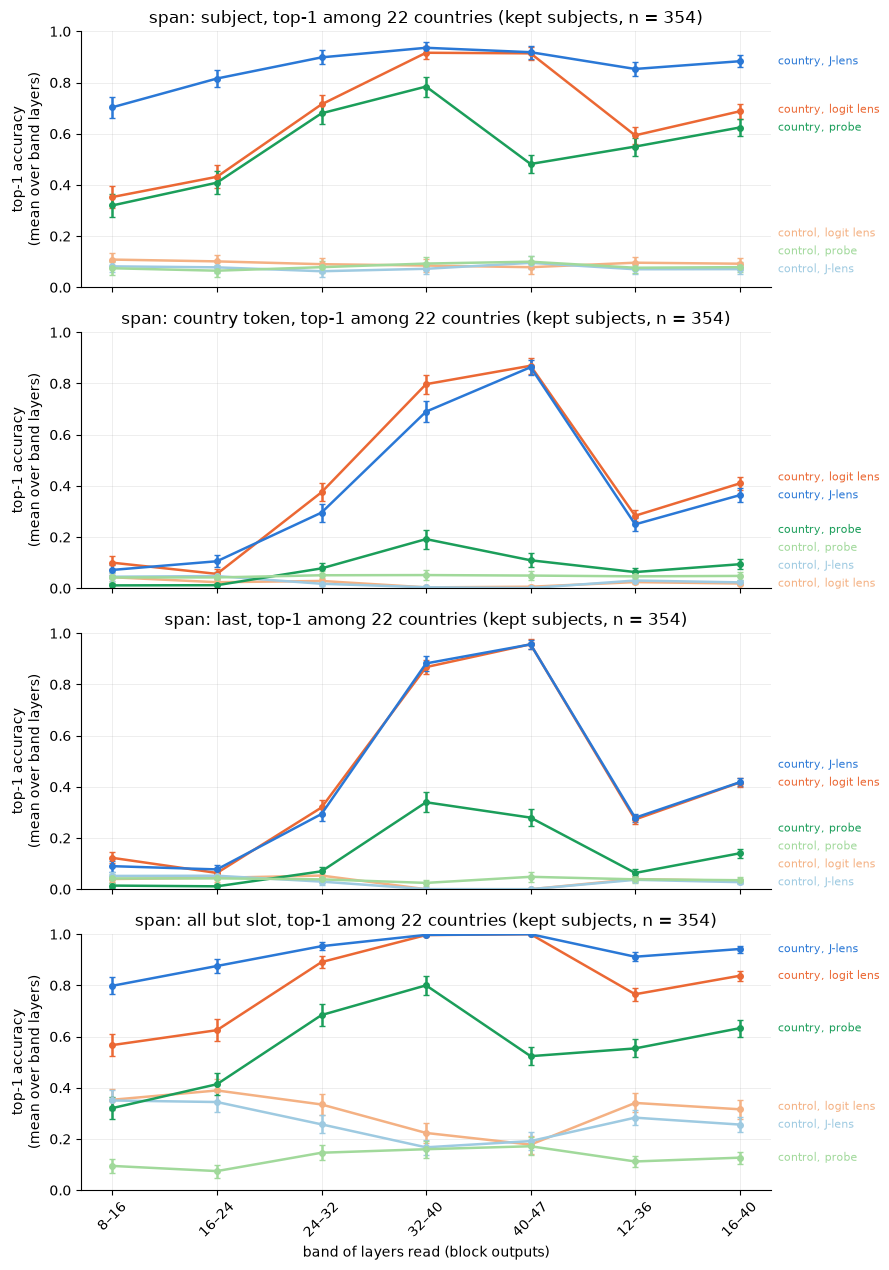

In [14]:
BAND_ONLY = BANDS[1:]  # the bands of concept_swap.ipynb; every inner layer is in the table
fig, axes = plt.subplots(len(PANEL_SPANS), 1, figsize=(9, 3.2 * len(PANEL_SPANS)), sharex=True, sharey=True)
for ax, span in zip(axes, PANEL_SPANS, strict=True):
    ends = []
    for method in METHODS:
        for kind, colors, name in (("intermediate", COLORS, "country"), ("control", CONTROL_COLORS, "control")):
            frame = kept22[kept22.span.eq(span) & kept22.lens.eq(method) & kept22.kind.eq(kind)]
            per_prompt = [band_accuracy(frame, band) for band in BAND_ONLY]
            mean = np.array([v.mean() for v in per_prompt])
            half = np.array([1.96 * v.std(ddof=1) / np.sqrt(len(v)) for v in per_prompt])
            ax.errorbar(range(len(BAND_ONLY)), mean, yerr=half, color=colors[method], marker="o", ms=4, lw=1.8,
                        capsize=2)
            ends.append((mean[-1], f"{name}, {method}", colors[method]))
    label_ends(ax, ends)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25, lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(f"span: {span}, top-1 among 22 countries (kept subjects, n = {prompts.kept.sum()})")
    ax.set_ylabel("top-1 accuracy\n(mean over band layers)")
axes[-1].set_xticks(range(len(BAND_ONLY)), BAND_TICKS[1:], rotation=45)
axes[-1].set_xlabel("band of layers read (block outputs)")
fig.tight_layout()
plt.show()

Per layer: share of kept prompts whose country is ranked first among the 22, one panel per
position, one line per readout (control in the table above).

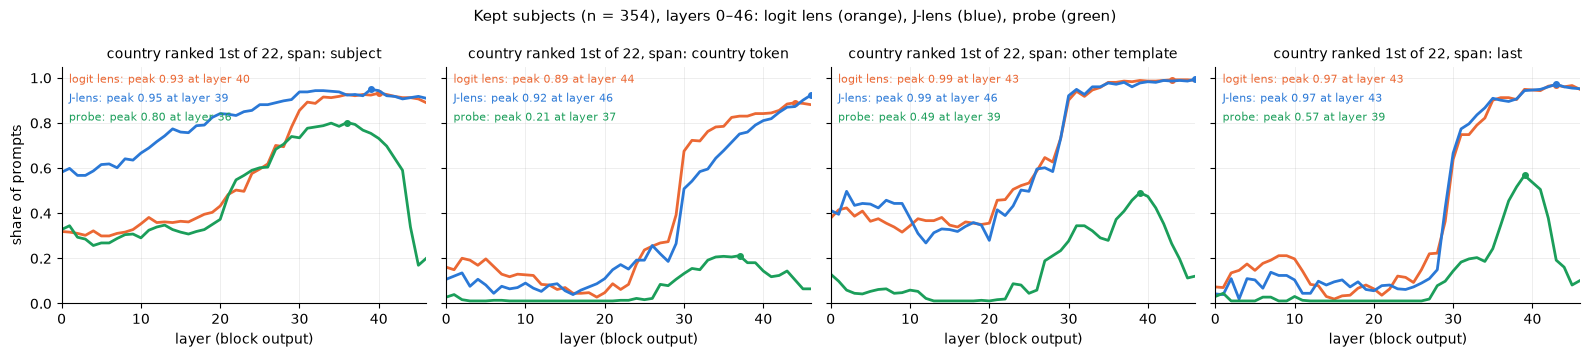

In [15]:
PROFILE_SPANS = ["subject", "country token", "other template", "last"]
fig, axes = plt.subplots(1, len(PROFILE_SPANS), figsize=(4 * len(PROFILE_SPANS), 3.6), sharey=True)
for ax, span in zip(axes, PROFILE_SPANS, strict=True):
    for m, method in enumerate(METHODS):
        sub = kept22[kept22.lens.eq(method) & kept22.kind.eq("intermediate") & kept22.span.eq(span)]
        curve = (np.stack(sub.ranks.to_numpy()) <= 1).mean(0)
        ax.plot(curve, color=COLORS[method], lw=2)
        peak = int(curve.argmax())
        ax.plot(peak, curve[peak], "o", color=COLORS[method], ms=4)
        ax.text(0.02, 0.97 - 0.08 * m, f"{method}: peak {curve[peak]:.2f} at layer {peak}", transform=ax.transAxes,
                color=COLORS[method], fontsize=8, va="top")
    ax.set_title(f"country ranked 1st of 22, span: {span}", fontsize=10)
    ax.set_xlabel("layer (block output)")
    ax.set_xlim(0, len(curve) - 1)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.25, lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("share of prompts")
fig.suptitle(f"Kept subjects (n = {prompts.kept.sum()}), layers 0–46: logit lens (orange), J-lens (blue), "
             "probe (green)", fontsize=11)
fig.tight_layout()
plt.show()

## 7. Conclusions

* **In the full vocabulary the last token barely shows the country** (pass@10: J 18%, logit
  31%), and only after the answer. Among the 22 countries, though, it is first from layer ~30
  (88% in layers 32–40 for both lenses): present, but outranked by the answer words.
* **The slot is a confound, not a readout.** At ` in` / ` from` the country is what the model
  predicts next, and both lenses read it equally (pass@10 96%). It is excluded from the headline
  span; including it (*all*) makes the two lenses look the same.
* **Subject tokens: the J-lens reads more, and earlier.** Full vocabulary: pass@10 55% vs 43%,
  pass@100 91% vs 80%, pass@1 equal (17%), control ≤ 1%. Among the 22 countries the J-lens leads
  most in early and middle layers (8–16: 70% vs 35%; 12–36: 85% vs 59%) and the two meet after
  layer 32. By family the J-lens leads for landmarks, cities and people, ties for companies and
  trails for foods.
* **The ` country` token carries the country under both lenses late, under the J-lens also in
  full-vocabulary rank.** Full vocabulary: J pass@10 67% vs logit 10% (J control 20%: it partly
  reads "a country"). Among the 22 countries both lenses reach 70–80% in layers 32–40.
* **Under the J-lens the bridge precedes the answer.** Country on the subject at a median layer
  17, language at the last token at 30: country first in 80% of prompts. The logit lens shows
  the opposite order (31 vs 28, language first in 75%).
* **The probe reads the country where the subject is named, not where it is used.** Top-1 among
  the 22 countries, layers 12–36 / 32–40: on the subject probe 55% / 78% (lenses 59–94%); at
  ` country` 6% / 19% (lenses 25–80%); at the last token 6% / 34% (lenses 27–88%); controls
  2–10%. Directions learned from explicit mentions find the country as an attribute of the
  subject token, but not the form in which it is carried to later positions; the lens directions
  (output-aligned) find both. This matches the swap results: probe swaps flip 64% of answers,
  J-lens swaps 92%.
* **Visibility weakly predicts swap success.** At the best J swap setting, success is 93% when the
  country reaches rank 1 (all but slot, swap band), 87% at rank 11–100 and 75% beyond (12 trials).
* **For the lens benchmark on latent intermediates:** report pass@k over all positions except
  next-token slots, next to a control word; for a closed candidate set, use per-layer top-1
  accuracy (averaged over a band) rather than a best-over-layers score, which saturates.